In [2]:
import copy
import math
import gc
import glob
import logging
import multiprocessing
import operator
import os
import subprocess
import itertools
import tempfile
import time

import numpy as np
import pandas as pd
from tqdm import tqdm
from subprocess import Popen, PIPE

from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import EnumerateStereoisomers
from rdkit.Chem import MolStandardize
from rdkit.Chem import rdDistGeom
from rdkit.Chem import rdMolAlign
from rdkit.ML.Cluster import Butina
from rdkit.Chem import DataStructs

OBABEL_PATH = "/chemotargets/shared/conda/envs/obabel/bin/obabel"
def obabel_protonate(mol, ph=7):
    """
    WARNING: DO NO NOT DISTRIBUTE THIS CODE.
    OpenBabel is under GPL license.
    DO NOT LINK DIRECTLY TO OBABEL LIBS

    NOT AVAILABLE IN RDKIT: USE BABEL EXECUTABLE
    Importing pybel and rdkit at the same time produces impredictive behaviour

    """

    cmd = [OBABEL_PATH, "-i mol", "-o mol"]

    if ph:
        cmd.append("-p {}".format(ph))

    p = Popen(" ".join(cmd), stdout=PIPE, stdin=PIPE, stderr=PIPE, shell=True)
    stdout, stderr = p.communicate(input=mol.encode('utf-8'))
    mol2 = stdout.decode('utf-8')
    return mol2


class Molecule(object):
    """
    Extends RDkit Mol class by composition """

    def __init__(self, mol=None):

        self._molecule = mol
        self.properties = {}

        if mol is not None:
            assert isinstance(mol, Chem.Mol)

        self.lines = None
        self._infile = None


    def __getattr__(self, attr):
        # Allows the class to be pickable avoiding RecursionError
        if attr == "molecule":
            raise AttributeError

        if attr == "_molecule":
            raise AttributeError

        return getattr(self.molecule, attr)

    def __setitem__(self, key, value):
        self.properties[key] = value
        if self.molecule is not None:
            self.molecule.SetProp(key, str(value))

    def __getitem__(self, key):
        try:
            return self.properties[key]
        except KeyError:
            return self.molecule.GetProp(key)

    def __delitem__(self, key):
        self.properties.remove(key)

    def __contains__(self, key):
        return key in self.properties

    def __str__(self):
        smiles = "NOT LOADED"
        if self.molecule:
            smiles = Chem.MolToSmiles(self.molecule)
        return "{} {}".format(self.__class__, smiles)

    @property
    def molecule(self):
        return self._molecule

    @molecule.setter
    def molecule(self, value):
        if value is not None:
            assert isinstance(value, Chem.rdchem.Mol)
        self._molecule = value

    @property
    def infile(self):
        return self._infile

    @infile.setter
    def infile(self, value):
        if value is not None:
            self._infile = value

    def get_molecule(self):
        return self.molecule

    def append(self, molecule):
        try:
            self.molecules.append(molecule)
        except AttributeError:
            self.molecules = [molecule]

    def get_properties(self):
        return self.properties

    def set_property(self, name, value):
        if name == "_Name":
            self.name = value
        self.properties[name] = value

    def keys(self):
        return self.properties.keys()

    def clear_properties(self):
        self.properties = {}
        for property in self.molecule.GetPropNames(includePrivate=True):
            self.molecule.ClearProp(property)

    def fix_charges(self):
        """
        Tries to fix unssigned charges
        Needs to have read the molecule with sanitize=False


        Based on:
        https://www.blopig.com/blog/2024/09/out-of-the-box-rdkit-valid-is-an-imperfect-metric-a-review-of-the-kekulizeexception-and-nitrogen-protonation-to-correct-this/
        """

        self.molecule.UpdatePropertyCache(strict=False)
        problems = Chem.DetectChemistryProblems(self.molecule)

        for problem in problems:

            if problem.GetType() =='AtomValenceException':

                atom = self.molecule.GetAtomWithIdx(problem.GetAtomIdx())

                if atom.GetAtomicNum() == 7 and atom.GetFormalCharge() == 0 and atom.GetExplicitValence() == 4:
                    atom.SetFormalCharge(1)

                if atom.GetAtomicNum() == 8 and atom.GetFormalCharge() == 0 and atom.GetExplicitValence() == 3:
                    atom.SetFormalCharge(1)

        Chem.SanitizeMol(self.molecule)

    def generate_conformers(self, n: int = 1,
                            rms: float = 0.5,
                            ref: bool = False,
                            seed: int = -1,
                            compute_energies: bool = False,
                            pH: int = 7,
                            fast: bool = False):
        """
        Generate conformers for the molecule.

        Args:
            n (int): Number of conformers to generate.
            rms (float): RMS threshold for conformer pruning.
            ref (bool): Flag indicating whether to add a reference conformer.
            seed (int): Random seed for conformer generation.
            compute_energies (bool): Flag indicating whether to compute conformer energies.
            fast (int): If true does NOT optimize conformer energies.

        Returns:
            conformers (list): List[Molecule] of generated conformers.
        """

        mol = self.molecule

        # Protonate
        if pH is not None:
            mol = Molecule(self.protonate(pH)).molecule

        # Adding Explicit Hydrogens
        mol = Chem.AddHs(mol, addCoords=True)
        refmol = Chem.AddHs(Chem.Mol(mol))

        # Generate conformers using RDKit
        param = rdDistGeom.ETKDGv2()
        param.randomSeed = seed
        param.pruneRmsThresh = rms
        param.maxAttempts = 500
        param.enforceChirality = True
        cids = rdDistGeom.EmbedMultipleConfs(mol=mol, numConfs=n, params=param)

        # No conformers coud be generated
        if len(cids) == 0:
            return []

        # Energy Optimization of each conformer
        if not fast:

            mp = AllChem.MMFFGetMoleculeProperties(mol, mmffVariant="MMFF94s")
            AllChem.MMFFOptimizeMoleculeConfs(mol, numThreads=1, mmffVariant='MMFF94s')
            rdMolAlign.AlignMolConformers(mol)

            # Prunning conformers after energy minimization

            selected = [cids[0]]
            for i, cid in enumerate(cids[1:]):
                j = i+1
                min_rmsd = []
                while j < len(cids):
                    # maxMatches kept low to keep running time reasonable.
                    bestrmsd = AllChem.GetBestRMS(mol, mol,  cids[i], cids[j], maxMatches=1000)
                    min_rmsd.append(bestrmsd)
                    j += 1
                    if bestrmsd < rms:
                        break
                if min(min_rmsd) > rms:
                    selected.append(cid)

            cids = selected

        # Split conformers in molecules

        conformers = []

        if ref:
            # Add reference conformer
            refmol.SetProp("_Name", self.name if self.name else "")
            refmol.SetProp("CID", "-1")
            refmol.SetProp("Energy", "")
            conformers.append(Molecule(refmol))

        if compute_energies:

            # Calculate energies sequentially
            energy = {}
            for cid in cids:
                e = self.calculate_energy(mol, mp, cid)
                energy[cid] = e

            sorted_cids = sorted(energy, key=energy.get)

            # Add conformers with energies
            for cid in sorted_cids:
                m = Chem.Mol(refmol, True)
                m.AddConformer(mol.GetConformer(cid))
                m = Molecule(m)
                m.set_properties(self.get_properties())
                m.name = self.name if self.name else ""
                m["CID"] = str(cid)
                m["Energy"] = str(energy[cid])
                conformers.append(m)
        else:
            # Add conformers without energies
            for cid in cids:
                m = Chem.Mol(refmol, True)
                m.AddConformer(mol.GetConformer(cid))
                m = Molecule(m)
                m.set_properties(self.get_properties())
                m.name = self.name if self.name else ""
                m["CID"] = str(cid)
                m.set_properties()
                conformers.append(m)

        return conformers

    def calculate_energy(self, mol, mp, cid):
        """
        Calculate the energy of a conformer using MMFF force field.

        Args:
            mol (Molecule): The molecule object.
            mp: The molecule properties object.
            cid (int): Conformer ID.

        Returns:
            energy (float): The calculated energy.
        """
        ff = AllChem.MMFFGetMoleculeForceField(mol, mp, confId=cid)
        return ff.CalcEnergy()



    def get_conformer(self, nconf=0):
        return self.GetConformer(nconf)

    def cluster_conformers(self, threshold=0.5, prune=False):

        dmat = AllChem.GetConformerRMSMatrix(self.molecule, prealigned=False)
        clusters = Butina.ClusterData(dmat, self.molecule.GetNumConformers(), threshold, isDistData=True, reordering=True)

        if not prune:
            return clusters

        else:
            cid = [x[0] for x in clusters]
            m = Chem.Mol(self.molecule, True)
            m.SetProp("_Name", self.name)

            for conformer in self.GetConformers():
                if conformer.GetId() not in cid:
                    continue
                m.AddConformer(conformer, assignId=True)

        return m


    @property
    def name(self):
        try:
            return self["_Name"]
        except KeyError:
            return

    @name.setter
    def name(self, name):
        self["_Name"] = name

    def set_properties(self, properties=None):

        if properties:
            self.properties = copy.deepcopy(properties)

        # Set properties
        self.properties.update({k: self.molecule.GetProp(k) for
                                k in self.molecule.GetPropNames(includePrivate=True) if
                                k not in self.properties})

        # Set name
        try:
            self.properties["_Name"] = self.molecule.GetProp("_Name")
        except KeyError:
            pass

        for key, value in self.properties.items():
            if key not in self.molecule.GetPropNames(includePrivate=True):
                self.molecule.SetProp(key,  str(value))
    def get_atom_fpt(self, niter=8):

        fpt = {}
        for atom in self.GetAtoms():
            fpt[atom.GetIdx()] = self.get_atom_fpt_by_atom(atom, niter=niter)

        return fpt

    def get_atom_fpt_by_atom(self, atom, niter=8):

        seen = set([atom.GetIdx()])
        current = [atom.GetIdx()]
        fpt = []

        for i in range(niter):

            fpt.append("".join(sorted([self.GetAtomWithIdx(x).GetSymbol() for x in current])))

            seen.update(current)

            current = [self.GetAtomWithIdx(x).GetNeighbors() for x in current]
            current = set([a.GetIdx() for neigh in current for a in neigh if a.GetIdx() not in seen])

        return ".".join([x for x in fpt if x])

    def get_substructure_rms(self, molecule, mcs=None):

        if mcs is None:
            mcs = rdFMCS.FindMCS([self.molecule, molecule.molecule], completeRingsOnly=True)
        pattern = Chem.MolFromSmarts(mcs.smartsString)

        a = Molecule(self.get_fragment_by_pattern(pattern))
        b = Molecule(molecule.get_fragment_by_pattern(pattern))

        rmsd = a.rmsd(b)
        return rmsd

    def get_fragment_by_pattern(self, pattern):

        core = Chem.ReplaceSidechains(self.molecule, pattern)

        for b in core.GetBonds():
            if b.GetBeginAtom().GetAtomicNum() == 0 and b.GetEndAtom().GetAtomicNum() == 0:
                core = Chem.RWMol(core)
                core.RemoveBond(b.GetBeginAtom().GetIdx(), b.GetEndAtom().GetIdx())
            elif b.GetBeginAtom().GetAtomicNum() == 0 or b.GetEndAtom().GetAtomicNum() == 0:
                b.SetBondType(Chem.BondType.SINGLE)
                b.SetIsAromatic(False)

        for a in core.GetAtoms():
            if (not a.IsInRing()):
                a.SetIsAromatic(False)
            if a.GetAtomicNum() == 0:
                a.SetAtomicNum(1)
                a.SetIsotope(0)
                a.SetIsAromatic(False)

        core = Chem.RemoveHs(core)

        return core

    def rmsd(self, reference, returnMatch=False):

        rmsd = Chem.rdMolAlign.CalcRMS(self.molecule,
                                       reference.molecule,
                                       symmetrizeConjugatedTerminalGroups=True)

        # Try uncharging the molecule
        if not rmsd:

            one = self.uncharge()
            other = reference.uncharge()

            rmsd = Chem.rdMolAlign.CalcRMS(one.molecule, other.molecule,
                                           symmetrizeConjugatedTerminalGroups=True)

        return rmsd

    def rmsd_advanced(self, reference, rdkit=True, returnMatch=False, max_tries=1000000):

        if rdkit:
            mapping = self.get_atom_mapping_rdkit(reference)
        else:
            mapping = self.get_atom_mapping_fingerprints(reference, max_tries=max_tries)

        rmsd, mappingBest = self.get_rmsd_for_mapping(reference, mapping)

        if returnMatch:
            return rmsd, mappingBest

        return rmsd

    def get_rmsd_for_mapping(self, reference, mapping):

        if not mapping:
            return None, None

        RMS = []
        for match in mapping:
            rms = 0
            for i, atom in enumerate(reference.GetAtoms()):

                pos1 = self.molecule.GetConformer(0).GetAtomPosition(match[atom.GetIdx()])
                pos2 = reference.GetConformer(0).GetAtomPosition(atom.GetIdx())

                p1 = np.array([pos1.x, pos1.y, pos1.z])
                p2 = np.array([pos2.x, pos2.y, pos2.z])

                rms += np.sum((p1-p2) ** 2)

            rms = math.sqrt(rms/reference.GetNumAtoms())
            RMS.append(rms)

        return min(RMS), mapping[np.argmin(np.array(RMS))]
    def get_atom_mapping_rdkit(self, reference):
        """
        Get atom mapping between two molecules using rdkit substructure matching
        """

        try:

            matches = self.molecule.GetSubstructMatches(reference.molecule,
                                                        uniquify=False,
                                                        useChirality=False,
                                                        useQueryQueryMatches=True)
        except Exception:
            return

        # Try uncharging the molecule
        if not matches:
            one = self.uncharge()
            other = reference.uncharge()
            try:
                matches = one.molecule.GetSubstructMatches(other.molecule,
                                                           uniquify=False,
                                                           useChirality=False,
                                                           useQueryQueryMatches=True)
            except Exception:
                return


        return matches

    def get_atom_mapping_fingerprints(self, reference, max_tries=1000000):

        fptref = self.get_atom_fpt(niter=8)
        fpt = reference.get_atom_fpt(niter=8)

        pairs = []
        for atom in self.GetAtoms():
            idx = atom.GetIdx()
            pairs.append([x for x in fptref if fptref[x] == fpt[idx]])

        matches = []
        for i, match in enumerate(itertools.product(*pairs)):

            if i > max_tries:
                break

            if len(set(match)) == len(match):
                matches.append(match)

        return matches

    def enumerate_tautomers(self, score=False, sort:bool=False):
        """ Enumerate tautomers """

        enumerator = MolStandardize.rdMolStandardize.TautomerEnumerator()
        tautomers = [Molecule(m) for m in enumerator.Enumerate(self.molecule)]
        [m.set_properties() for m in tautomers]

        if score:

            for tautomer in tautomers:
                score = enumerator.ScoreTautomer(tautomer.molecule)
                tautomer["tautomer_score"] = score

            tautomers.sort(key=lambda mol: float(mol["tautomer_score"]), reverse=True)

        return tautomers

    def enumerate_stereoisomers(self):


        Chem.FindMolChiralCenters(self.molecule, includeUnassigned=True)

        options = EnumerateStereoisomers.StereoEnumerationOptions(unique=False)
        isomers = [Molecule(m) for m in EnumerateStereoisomers.EnumerateStereoisomers(self.molecule, options=options)]

        # Setting parent properties
        [m.set_properties(self.get_properties()) for m in isomers]
        return isomers

    def count_charged_atoms(self) -> int:
        """
        Counts the number of charged atoms in a molecule.
        """
        return sum([1 for at in self.GetAtoms() if at.GetFormalCharge() != 0])

    def check_protonation(self):
        """
        Check for unrealistic overprotonation """

        # Number of charged atoms <= 3
        if self.count_charged_atoms() > 3:
            return False

        # Net Charge [-1, 0, 1]
        if Chem.GetFormalCharge(self.molecule) not in [-1, 0, 1]:
            return False

        return True

    def protonate(self, ph: int = 7):

        mol = obabel_protonate(Chem.MolToMolBlock(self.molecule), ph=ph)
        m = Chem.MolFromMolBlock(mol, sanitize=True)

        # Openbabel tends to overprotonate.
        # Discard compounds with multiple charges

        if m is None or Molecule(m).check_protonation() is False:
            return self.molecule
        return m



class Molecules:
    """
    Manages a list of molecules (Molecule) """

    def __init__(self, infile=None, molecules=None, name=None, read=False,
                 rdkit=True, removeHs=True, sanitize=True,
                 format="sdf", **kwargs):

        self.name = name
        self.molecules = molecules
        self.infile = infile
        self.sanitize = sanitize
        self.removeHs = removeHs
        self.format = format
        config =  {
            "smiles_separator": "\t",
            "smiles_header": True,
            "format_file_extensions": {
                "sdf": [".sdf", ".sd"],
                "smi": [".smi", ".smiles"]}}

        self.config = copy.deepcopy(config)
        self.rdkit = rdkit

        self.config.update(kwargs)

        self.size = None
        self.modified = False

        self.index = None
        self._iter = None

        # Convert rdkit.Chem to Molecule
        if molecules is not None:
            self.molecules = [Molecule(x) if isinstance(x, Chem.Mol)
                              else x for x in molecules]

        if read:
            self.load()

        self.operators = {
            "==": operator.eq,
            "<": operator.lt,
            "<=": operator.le,
            ">": operator.gt,
            ">=": operator.ge,
        }


        self._mfpgen = None

    def __repr__(self):

        info = [
            str(self.__class__),
        ]

        if self.infile:
            info.append(f"INFILE:\t{os.path.abspath(self.infile)}")

        info.append(f"SIZE:\t{len(self)}")

        info.append(f"READ:\t{self.molecules is not None}")

        return "\n".join(info)

    def __len__(self):

        if self.molecules is not None:
            return len(self.molecules)

        elif self._iter:
            try:
                return len(self._iter)
            except TypeError:
                # Estimate from sdf
                grep = subprocess.Popen(["egrep", "-c",  r'^\${4}', self.infile], stdout=subprocess.PIPE, shell=False)
                stdout, stderr = grep.communicate()
                try:
                    return int(stdout)
                except ValueError:
                    return 0
        else:
            self.set_iter(rdkit=self.rdkit)
            return len(self)

    def __getitem__(self, idx):
        self.load()
        return self.molecules[idx]

    def __iter__(self):

        if self.molecules is not None:
            for mol in self.molecules:
                if not mol.molecule and self.rdkit:
                    mol.load_from_molBlock()
                yield mol
            return

        elif self._iter is None:
            self.set_iter(rdkit=self.rdkit)

        if self._iter is not None and self.molecules is None:
            for mol in self._iter:
                if mol:
                    if self.rdkit:
                        m = Molecule(mol)
                        m.set_properties()
                        yield m
                    else:
                        yield mol

        # Reset the iterator after all molecules have been iterated
        self.reset()

    def set_iter(self, rdkit=True):
        """
        Set iterator for molecules.

        If rdkit is true uses rdkit Suppliers, otherwise treats molecules as
        text lines """

        if self._iter:
            return

        if self.molecules is not None:
            self._iter = self.iter_molecules(rdkit=rdkit)
            return

        if self.infile is None:
            return

        extension = os.path.splitext(self.get_infile())[-1]

        if rdkit is True:


            if extension in (".sdf", ".sd"):
                self._iter = Chem.ForwardSDMolSupplier(self.get_infile(),
                                                       sanitize=self.sanitize,
                                                       removeHs=self.removeHs)

            if extension in (".smi"):
                self._iter = Chem.SmilesMolSupplier(self.get_infile(),
                                                    delimiter=self.config["smiles_separator"],
                                                    titleLine=self.config["smiles_header"])
        else:

            if extension in (".sdf", ".sd"):
                self._iter = self.iter_sdf()
            if extension in (".smi"):
                self._iter = self.iter_smi()
    def fix_charges(self):
        for _ in self.fix_charges_generator():
            pass

    def fix_charges_generator(self):
        for m in self:
            m.fix_charges()
            yield m

    def read(self, infile):
        self.infile = infile
        self.load()

    def load(self, sanitize=None):

        if sanitize is not None:
            self.sanitize = sanitize

        if self.molecules is None:
            self.molecules = [m for m in self]
            [m.set_properties() for m in self]

    def get_infile(self):
        return self.infile

    def from_dataframe(self, df, molName="mol", name="_Name", fields=[],
                       rdkit=False):
        """ Load molecules from a Pandas DataFrame """


        self.molecules = []
        for i, row in df.iterrows():

            if rdkit:
                m = Molecule(row[molName])
            else:
                m = row[molName]

            m.clear_properties()

            m.clear_properties()
            m.name = row[name]

            for field in fields:
                m[field] = row[field]

            m.set_properties()

            self.molecules.append(m)

    def dataframe(self):
        """
        Create a df with mol properties.

        Only fields of the first molecule are used
        """

        data = []

        for i, mol in enumerate(self):

            mol.set_properties()

            if i == 0:
                columns = list(mol.get_properties().keys())

            # If field not in molecule properties use NAN
            data.append([mol.properties.get(x, np.nan) for x in columns] + [mol.molecule])

        df = pd.DataFrame(data, columns=columns + ["mol"])

        return df


    def write_sdf(self, outfile):
        w = Chem.SDWriter(outfile)
        for mol in self:
            try:
                mol.set_properties()
                w.write(mol.molecule)
            except: continue
        w.flush()


    def reset(self, rdkit=None):

        if rdkit is not None:
            self.rdkit = rdkit

        self._iter = None
        self.set_iter(rdkit=self.rdkit)



    def split(self, n=10, files=False, overwrite=False,
              generator=False, output_dir=".", format_=None, size=None):

        if format_ is None:
            if self.infile:
                format_ = self.infile.split(".")[-1]
            else:
                format_ = "sdf"

        if not os.path.isdir(output_dir):
            raise IOError(f"Output path {output_dir} doesn't exist.")

        # If molecules already loaded and no files needed
        if self.molecules is not None and files is False:
            return [ x for x in np.array_split(self.molecules, n) if x.size > 0]

        splitgen = self.split_generator(n=n, files=files,
                                        output_dir=output_dir,
                                        format_=format_,
                                        size=size)

        if generator:
            return splitgen

        return list(splitgen)

    def split_generator(self, n=10, files=False, output_dir=".",
                        format_="sdf", read=True, size=None):
        """
        Split molecules in chunks """

        if n is not None:
            size = len(self)
            chunk_size = math.ceil(size / n)
        else:
            chunk_size = size

        i = 0
        ichunk = 0

        for imol, mol in enumerate(self):

            if n == -1:
                ftmp = open(os.path.join(output_dir,"{}.sdf".format(mol.get_name())), "w")

                if format_ == "sdf":
                    w = Chem.SDWriter(ftmp)
                elif format_ == "smi":
                    w = self.get_smiles_writer(ftmp)

                w.write(mol.molecule)
                w.flush()
                ftmp.close()
                continue

            if i == chunk_size or imol == 0:

                if imol != 0:
                    w.close()
                    ftmp.close()
                    yield ftmp.name

                if files is True:
                    ftmp = open(os.path.join(output_dir, "{1}.{0:03d}.{2}".format(ichunk, os.path.splitext(
                        os.path.basename(self.infile))[0], format_)), "w")

                else:
                    ftmp = tempfile.NamedTemporaryFile("w",
                                                    dir=output_dir,
                                                    delete=False,
                                                    suffix=".{:03d}.sdf".format(ichunk))

                    # Reopen as regular file to avoid error. Bug in tempfile ?
                    ftmp2 = open(ftmp.name, "w")
                    ftmp.close()
                    ftmp = ftmp2


                if format_ == "sdf":
                    if self.rdkit:
                        w = Chem.SDWriter(ftmp)
                    else:
                        w = open(ftmp.name, "w")

                elif format_ == "smi":
                    w = self.get_smiles_writer(ftmp)

                i = 0
                ichunk += 1

            if self.rdkit:
                w.write(mol.molecule)
            else:
                w.writelines(mol.lines)

            i += 1

        if i > 0:
            w.close()
            yield ftmp.name

    def multiprocess(self, function, nsplits=None, size=None, ncpus=1,
                     format_="sdf",
                     outfile=None,
                     kwargs={},
                     clean=True,
                     external=False):
        """
        Execute molecules methods in parallel.

        It splits the molecule set, executes the function in each split and
        joins all the results.

        It is file based and uses a temporary folder in /tmp

        """

        if nsplits is None and size is None:
            nsplits = ncpus

        if outfile is None:
            outfile = "{}.{}.sdf".format(
                os.path.splitext(os.path.basename(self.infile))[0],
                function.__name__)

        # Skip Multiprocessing if ncpus and nsplits = 1
        if ncpus == 1 and nsplits == 1:
            kwargs["outfile"] = outfile
            if external is True:
                kwargs["molecules"] = self
            return function(**kwargs)

        # Callback functions

        def task_failed(result, chunk):
            self.logger.error(f"Error for chunk ({chunk}):{result}")

        def task_completed(result, chunk):
            #print(result)
            #self.logger.info(f"Task completed for chunk: {chunk}")
            pass

        # Create temporary folder
        with tempfile.TemporaryDirectory(prefix=f"molecules.{function.__name__}.",
                                         # delete=clean # Only available in
                                         # python >= 3.12
                                         ) as basepath:

            output_files = []

            # If ncpus = 1, use ThreadPool instead of Pool to allow
            # parallelization inside the function. Nested Pools can not exist

            if ncpus > 1:
                Pool = multiprocessing.Pool
            elif ncpus == 1:
                Pool = multiprocessing.pool.ThreadPool

            try:
                with Pool(ncpus) as pool:

                    for i, chunk in enumerate(self.split(
                        n=nsplits, size=size, files=True, generator=True,
                        overwrite=True, format_=format_,
                        output_dir=basepath)):

                        output_file = os.path.join(basepath, f"output_{i}.{format_}")
                        output_files.append(output_file)

                        molecules = Molecules(infile=chunk)

                        if external is False:
                            function = getattr(molecules, function.__name__)
                        else:
                            kwargs["molecules"] = molecules

                        res = pool.apply_async(function,
                                               kwds={**kwargs, "outfile": output_file},
                                               callback=lambda result, c=chunk: task_completed(result, c),
                                               error_callback=lambda result, c=chunk: task_failed(result, c))
                    # Close the pool
                    pool.close()

                    # Progress Bar waiting for all the tasks to be completed.
                    with tqdm(total=nsplits, desc=f"Molecule Multiprocessing ({function.__name__})") as pbar:
                        while pool._state == 'RUN' or pool._cache:
                            pbar.n = len(glob.glob(os.path.join(basepath, "output_*")))
                            pbar.refresh()
                            time.sleep(1)

                    # Wait for all tasks to complete. Should already be done
                    pool.join()

            finally:
                # The whole temprary folder is removed at the end
                #remove chunk files
                #[os.remove(fname) for fname in chunk_files]
                logging.info('MERGING FILES')
                with open(outfile, 'w',encoding='utf-8') as f:
                    for i, fname in enumerate(output_files):
                        if os.path.isfile(fname):
                            with open(fname) as infile:
                                # For smiles skip the header in all but
                                # the first file.
                                if format_ == "smi" and i > 0:
                                    infile.readline()
                                f.write(infile.read())
                            #os.remove(fname)
                gc.collect()

    def sort(self, key_, numeric=False, reverse=False):

        self.load()

        foo = lambda m: m[key_]
        if numeric:
            foo = lambda m: float(m[key_])

        self.molecules.sort(key=foo, reverse=reverse)

    def get_atom_fpt(self, atom, niter=6):

        seen = set([atom.GetIdx()])
        current = [atom.GetIdx()]
        fpt = ""

        for i in range(niter):

            fpt += "".join(sorted([self.GetAtomWithIdx(x).GetSymbol() for x in current]))
            seen.update(current)

            current = [self.GetAtomWithIdx(x).GetNeighbors() for x in current]
            current = set([a.GetIdx() for neigh in current for a in neigh if a.GetIdx() not in seen])

        return fpt

    def standardize(self, outfile=None, **kwargs):


        self.modified = True
        standardizer = MolStandardize.Standardizer()

        if outfile is not None:
            w = self.get_writer(outfile)

        for m in self:
            std = m.standardize(standardizer, **kwargs)
            if outfile is not None and std is not None:
                w.write(std)

        if self.molecules:
            self.molecules = [m for m in self.molecules if m.molecule is not None]
        return self.molecules

    def standardize_iter(self, **kwargs):

        standardizer = MolStandardize.Standardizer()

        for m in self:
            m.standardize(standardizer, **kwargs)
            yield m

    def enumerate(self, start=1, inplace=False, key="num"):

        if not inplace:
            for i, mol in enumerate(self):
                mol[key] = f"# {i+start:d}"
                yield mol
        else:
            self.load()
            for i, mol in enumerate(self):
                mol[key] = f"# {i+start:d}"
            return

    def prepare(self,
                conformers: bool = True,
                tautomers: bool = False,
                stereoisomers: bool = True,
                standardize: bool = True,
                nconf: int = 10,
                ref: bool = False,
                compute_energies: bool = False,
                pH: int = 7.4,
                outfile: str = None,
                seed: int = -1,
                fastconf: bool = False,
                maxtautomers: int = 10,
                maxstereoisomers: int = 10):
        """
        Prepare a set of molecules by generating tautomers, stereoisomers,
        and conformers as specified.

        Parameters:

            - conformers (bool, optional): Whether to generate conformers for
            each molecule. Default is True.

            - tautomers (bool, optional): Whether to generate tautomers for
            each molecule. Default is False.

            - stereoisomers (bool, optional): Whether to generate stereoisomers
            for each molecule. Default is True.

            - nconf (int, optional): Number of conformers to generate for
            each molecule if conformers is True. Default is 1.

            - ref (bool, optional): Whether to use reference conformers.
            Default is False.

            - compute_energies (bool, optional): Whether to compute energies
            for each conformer. Default is False.

            - pH (int, optional): pH value to consider during conformer
            generation. Default is 7.

            - output (str, optional): Path to the output file to save the
            processed molecules in SDF format.
            If None, the file is not written. Default is None.

            - fastconf: Skip energy optimization when generating conformers

        Returns:
        str or None: Path to the output file if specified and written
        successfully, otherwise None.

        Raises:
        IOError: If there is an error writing the output file.
        """

        # Need to load in memory as some molecule transformations are done
        # in place.

        self.load()
        self.logger.info(f"Preparing {len(self)} Molecules")

        try:
            tmp_mols = self

            if standardize:
                tmp_mols.standardize()
                self.logger.info(f"Molecules after Standardization: {len(tmp_mols)}")

            if tautomers:

                new_mols = Molecules(molecules=[])

                for m in tmp_mols:

                    try:
                        tautomer_molecules = m.enumerate_tautomers(score=True)
                    except Exception as e:
                        self.logger.warning(e)
                        tautomer_molecules =  [m]

                    # Sort by similarity to starting molecule
                    fp = AllChem.GetMorganFingerprint(m.molecule, 2)
                    tautomer_molecules.sort(key=lambda x: DataStructs.TanimotoSimilarity(fp,
                        AllChem.GetMorganFingerprint(x.molecule, 2)), reverse=True)

                    interval = len(tautomer_molecules) // maxtautomers
                    if interval > 0:
                        new_mols.extend(tautomer_molecules[::interval])
                    else:
                        new_mols.extend(tautomer_molecules)


                tmp_mols = new_mols
                self.logger.info(f"Molecules after Tautomer Enumeration: {len(tmp_mols)}")

            if stereoisomers:
                tmp_mols = Molecules(molecules=[stereoisomer for m in tmp_mols for stereoisomer in m.enumerate_stereoisomers()])
                self.logger.info(f"Molecules after Stereoisomer Enumeration: {len(tmp_mols)}")

            if conformers:
                tmp_mols = Molecules(molecules=[conformer for m in tmp_mols for conformer in m.generate_conformers(
                    n=nconf, ref=ref, compute_energies=compute_energies, pH=pH, seed=seed, fast=fastconf)])
                self.logger.info(f"Molecules after Conformer Enumeration: {len(tmp_mols)}")

            if outfile:
                tmp_mols.write_sdf(outfile=outfile)
                if os.path.isfile(outfile):
                    return outfile
                else:
                    raise IOError(f"Failed to write output file: {outfile}")
            else:
                return tmp_mols

        except Exception as e:
            print(f"Error preparing molecules: {e}")
            raise e
            return None

def defragment(mol, polarR: bool = False):

    fragment = Chem.Mol(mol)

    for atom in fragment.GetAtoms():
        if atom.GetAtomicNum() == 0:

            if polarR:
                neighbors = atom.GetNeighbors()
                if neighbors and neighbors[0].GetSymbol() != "C":
                    atom.SetAtomMapNum(0)
                    atom.SetIsotope(0)
                    continue

            atom.SetAtomicNum(1)
            atom.SetIsotope(0)

    try:
        fragment = Chem.RemoveAllHs(fragment, sanitize=True)
        Chem.SanitizeMol(fragment)
        return fragment
    except Exception:
        return None

#   success rate as function of template similarity

/tmp/ipykernel_2948609/1568751620.py:40: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_counts = df.groupby('Mimic_bin').size()
/tmp/ipykernel_2948609/1568751620.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(data=df, x='Mimic_bin', y=rmsd_col, palette=custom_palette, cut=0)


✅ 3D Median RMSD distribution plot with significance brackets saved!


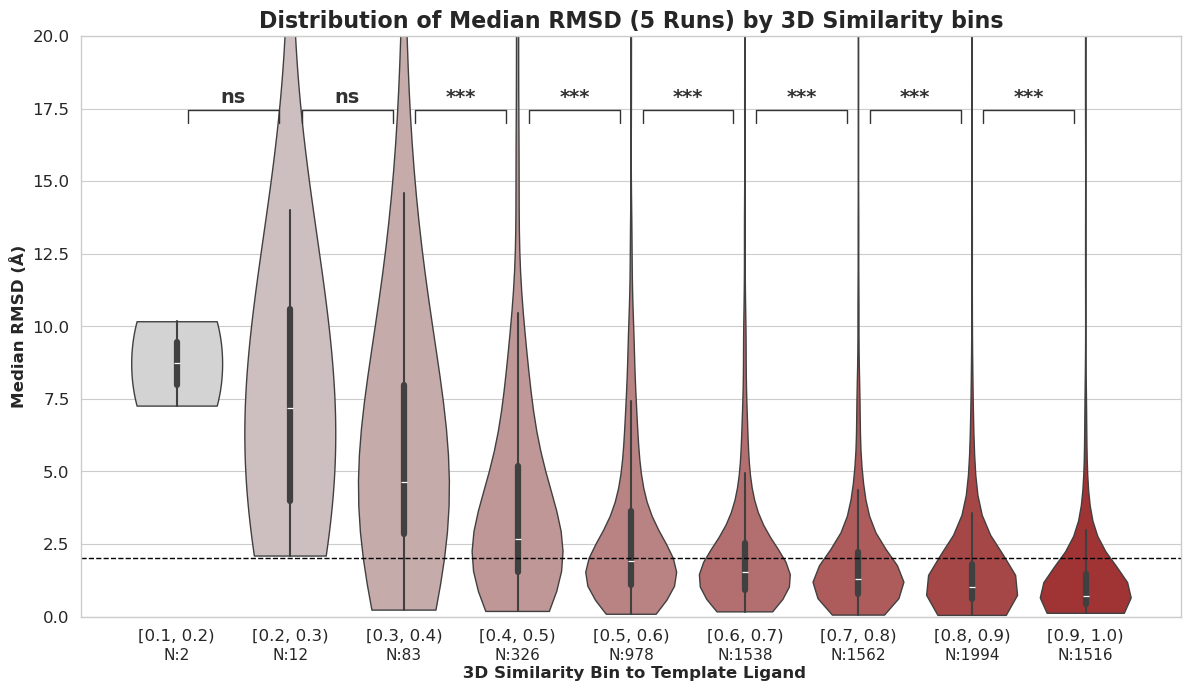

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

def create_median_violin_plot(file_list):

    dfs = []
    for file in file_list:
        try:
            df_run = pd.read_csv(file)
            dfs.append(df_run)
        except FileNotFoundError:
            print(f"Error: The file '{file}' was not found. Skipping.")

    if not dfs:
        print("No files were loaded. Exiting.")
        return

    combined_df = pd.concat(dfs, ignore_index=True)

    rmsd_col = "rmsd"

    df = combined_df.groupby('PDB').agg({
        rmsd_col: 'median',
        'Mimic_Score': 'first'
    }).reset_index()


    bins = np.round(np.arange(0, 1.15, 0.1), 2)
    labels = [f"[{bins[i]:.1f}, {bins[i+1]:.1f})" for i in range(len(bins)-1)]
    df.dropna(subset=['Mimic_Score'], inplace=True)
    df['Mimic_bin'] = pd.cut(df['Mimic_Score'], bins=bins, labels=labels, include_lowest=True, right=False)
    df['Mimic_bin'] = df['Mimic_bin'].astype(str)


    final_bin_order = sorted(df['Mimic_bin'].unique())
    df['Mimic_bin'] = pd.Categorical(df['Mimic_bin'], categories=final_bin_order, ordered=True)
    bin_counts = df.groupby('Mimic_bin').size()

    sns.set_theme(style="whitegrid", context="paper")
    plt.figure(figsize=(12, 7))

    num_bins = len(df['Mimic_bin'].cat.categories)
    custom_palette = sns.blend_palette(["lightgray", "firebrick"], n_colors=num_bins)

    ax = sns.violinplot(data=df, x='Mimic_bin', y=rmsd_col, palette=custom_palette, cut=0)


    plt.axhline(y=2.0, color='black', linestyle='--', lw=1)


    for i, bin_label in enumerate(bin_counts.index):
        count = bin_counts[bin_label]
        ax.text(i, -1.6, f"N:{count}", ha='center', va='bottom', fontsize=11)

    categories = df['Mimic_bin'].cat.categories

    for i in range(len(categories) - 1):
        cat1, cat2 = categories[i], categories[i+1]

        data1 = df[df['Mimic_bin'] == cat1][rmsd_col].dropna()
        data2 = df[df['Mimic_bin'] == cat2][rmsd_col].dropna()

        if len(data1) and len(data2):
            stat, p = mannwhitneyu(data1, data2, alternative='two-sided')

            if p <= 0.001:
                sig = '***'
            elif p <= 0.01:
                sig = '**'
            elif p <= 0.05:
                sig = '*'
            else:
                sig = 'ns'

            max_val_in_range = max(
                data1[data1 < 28].max() if len(data1[data1 < 28]) > 0 else 0,
                data2[data2 < 28].max() if len(data2[data2 < 28]) > 0 else 0
            )


            y_pos = 17

            bracket_height = 0.45

            x_left = i + 0.1
            x_right = i + 1 - 0.1


            ax.plot([x_left, x_left, x_right, x_right],
                    [y_pos, y_pos + bracket_height, y_pos + bracket_height, y_pos],
                    lw=1, c='#333333')


            ax.text(i + 0.5, y_pos + bracket_height + 0.1, sig,
                    ha='center', va='bottom', color='#333333', fontsize=14, fontweight='bold')

    plt.title('Distribution of Median RMSD (5 Runs) by 3D Similarity bins', fontsize=16, fontweight='bold')
    plt.xlabel('\n 3D Similarity Bin to Template Ligand', fontsize=12, fontweight='bold')
    plt.ylabel('Median RMSD (Å)', fontsize=12, fontweight='bold')
    plt.xticks(rotation=0, ha='center')
    plt.tick_params(axis="both", which="major", labelsize=12)

    plt.ylim(0, 20)

    plt.tight_layout()
    plt.savefig(f'{YOUR_PATH}/Images/3D_median_rmsd_distribution_N_ALL_stats.png', dpi=500)



if __name__ == "__main__":

    run_files = [
        f"{YOUR_PATH}/rmsd_validation/MultiRun/run{i}_rmsd_results_fixed.csv"
        for i in range(1, 6)
    ]

    create_median_violin_plot(run_files)

/tmp/ipykernel_2948609/2353357051.py:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_counts = df.groupby('Tanimoto_bin').size()
/tmp/ipykernel_2948609/2353357051.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(data=df, x='Tanimoto_bin', y=rmsd_col, palette=custom_palette, cut=0)


✅ 2D Median RMSD distribution plot with significance brackets saved!


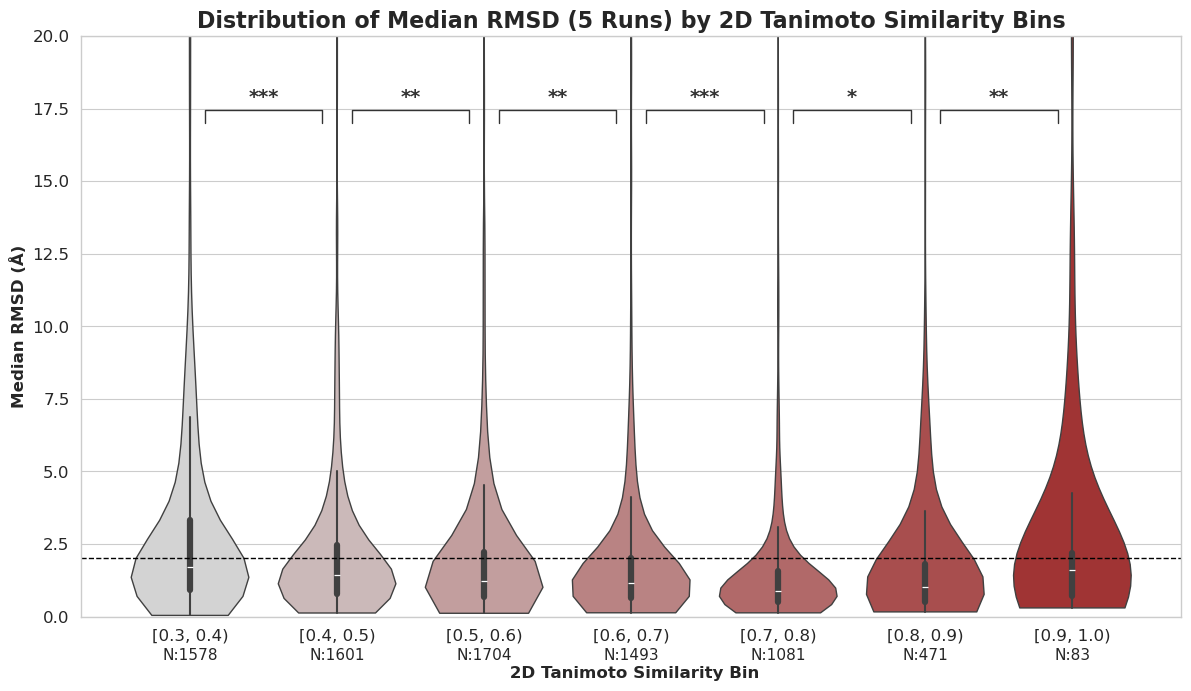

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

def create_median_violin_plot_2d(file_list):

    dfs = []
    for file in file_list:
        try:
            df_run = pd.read_csv(file)
            dfs.append(df_run)
        except FileNotFoundError:
            print(f"Error: The file '{file}' was not found. Skipping.")

    if not dfs:
        print("No files were loaded. Exiting.")
        return

    combined_df = pd.concat(dfs, ignore_index=True)

    rmsd_col =  'rmsd'

    df = combined_df.groupby('PDB').agg({
        rmsd_col: 'median',
        'Tanimoto2D': 'first'
    }).reset_index()

    df.dropna(subset=['Tanimoto2D'], inplace=True)
    df['Tanimoto2D'] = df['Tanimoto2D'].round(4)
    # Force all entries == 0.3 to equal exactly 0.3 so they fall into the [0.3, 0.4) bin (float maath made them fall in previous bin)
    df.loc[df['Tanimoto2D'] <= 0.3, 'Tanimoto2D'] = 0.3

    bins = np.round(np.arange(0.3, 1.15, 0.1), 2)
    labels = [f"[{bins[i]:.1f}, {bins[i+1]:.1f})" for i in range(len(bins)-1)]

    df['Tanimoto_bin'] = pd.cut(df['Tanimoto2D'], bins=bins, labels=labels, include_lowest=True, right=False)
    df['Tanimoto_bin'] = df['Tanimoto_bin'].astype(str)

    final_bin_order = sorted(df['Tanimoto_bin'].unique())
    df['Tanimoto_bin'] = pd.Categorical(df['Tanimoto_bin'], categories=final_bin_order, ordered=True)
    bin_counts = df.groupby('Tanimoto_bin').size()


    sns.set_theme(style="whitegrid", context="paper")
    plt.figure(figsize=(12, 7))

    num_bins = len(df['Tanimoto_bin'].cat.categories)
    custom_palette = sns.blend_palette(["lightgray", "firebrick"], n_colors=num_bins)

    ax = sns.violinplot(data=df, x='Tanimoto_bin', y=rmsd_col, palette=custom_palette, cut=0)


    plt.axhline(y=2.0, color='black', linestyle='--', lw=1)


    for i, bin_label in enumerate(bin_counts.index):
        count = bin_counts[bin_label]
        ax.text(i, -1.6, f"N:{count}", ha='center', va='bottom', fontsize=11)

    categories = df['Tanimoto_bin'].cat.categories

    for i in range(len(categories) - 1):
        cat1, cat2 = categories[i], categories[i+1]

        data1 = df[df['Tanimoto_bin'] == cat1][rmsd_col].dropna()
        data2 = df[df['Tanimoto_bin'] == cat2][rmsd_col].dropna()

        if len(data1) > 0 and len(data2) > 0:
            stat, p = mannwhitneyu(data1, data2, alternative='two-sided')

            if p <= 0.001:
                sig = '***'
            elif p <= 0.01:
                sig = '**'
            elif p <= 0.05:
                sig = '*'
            else:
                sig = 'ns'


            y_pos = 17

            bracket_height = 0.45
            x_left = i + 0.1
            x_right = i + 1 - 0.1


            ax.plot([x_left, x_left, x_right, x_right],
                    [y_pos, y_pos + bracket_height, y_pos + bracket_height, y_pos],
                    lw=1, c='#333333')


            ax.text(i + 0.5, y_pos + bracket_height + 0.1, sig,
                    ha='center', va='bottom', color='#333333', fontsize=14, fontweight='bold')


    plt.title('Distribution of Median RMSD (5 Runs) by 2D Tanimoto Similarity Bins', fontsize=16, fontweight='bold')
    plt.xlabel('\n 2D Tanimoto Similarity Bin', fontsize=12, fontweight='bold')
    plt.ylabel('Median RMSD (Å)', fontsize=12, fontweight='bold')
    plt.xticks(rotation=0, ha='center')
    plt.tick_params(axis="both", which="major", labelsize=12)

    plt.ylim(-0, 20)

    plt.tight_layout()
    plt.savefig(f'{YOUR_PATH}/Images/2D_median_rmsd_distribution_N_ALL_stats.png', dpi=300)

if __name__ == "__main__":

    run_files = [
        f"{YOUR_PATH}/rmsd_validation/MultiRun/run{i}_rmsd_results_fixed.csv"
        for i in range(1, 6)
    ]


    create_median_violin_plot_2d(run_files)

/tmp/ipykernel_1502652/3042230934.py:104: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


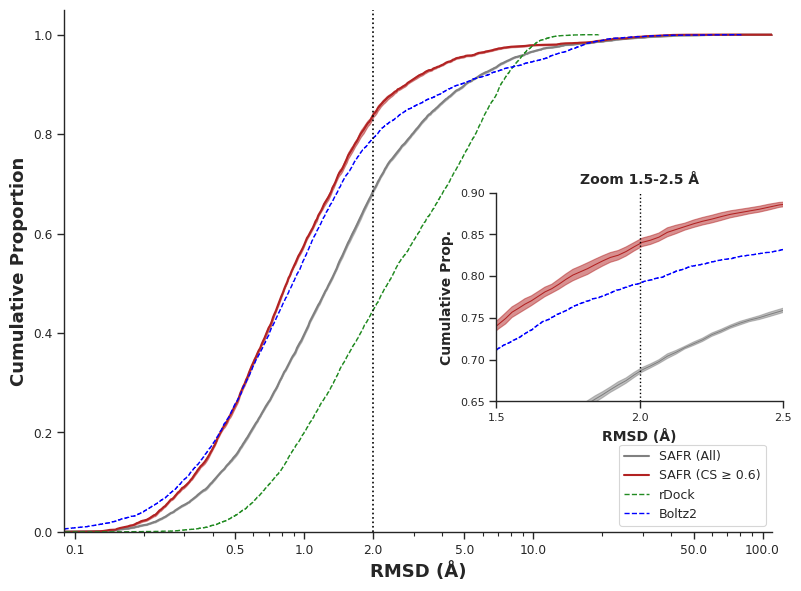

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.ticker import ScalarFormatter
from scipy.interpolate import interp1d
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

def create_comparison_cdf_plot_log():
    sns.set_theme(style="ticks", context="paper")
    fig, ax = plt.subplots(figsize=(8, 6))

    base_path = f"{YOUR_PATH}/rmsd_validation/MultiRun/run{}_rmsd_results_fixed.csv"
    run_numbers = range(1, 6)
    common_rmsd_grid = np.logspace(np.log10(0.09), np.log10(110), 500)

    all_cdfs, filtered_cdfs = [], []

    # Inset Axes setup
    ax_ins = inset_axes(ax, width="45%", height="40%", loc=5,
                        bbox_to_anchor=(0.15, -0.05, 0.9, 1),
                        bbox_transform=ax.transAxes, borderpad=2)
    ax_ins.set_facecolor('white')

    for i in run_numbers:
        file_path = base_path.format(i)
        try:
            df = pd.read_csv(file_path)
            rmsd_col = 'rmsd' if 'rmsd' in df.columns else 'First_RMSD'
            conf_col = 'Confidence_Score' if 'Confidence_Score' in df.columns else 'confidence_score'

            # All SAFR
            data_all = np.sort(df[rmsd_col].dropna().values)
            y_all = np.arange(1, len(data_all) + 1) / len(data_all)
            all_cdfs.append(interp1d(data_all, y_all, bounds_error=False, fill_value=(0, 1))(common_rmsd_grid))

            # High Confidence
            if conf_col in df.columns:
                df_filt = df[df[conf_col] >= 0.6].copy()
                if not df_filt.empty:
                    data_f = np.sort(df_filt[rmsd_col].dropna().values)
                    y_f = np.arange(1, len(data_f) + 1) / len(data_f)
                    filtered_cdfs.append(interp1d(data_f, y_f, bounds_error=False, fill_value=(0, 1))(common_rmsd_grid))
        except Exception as e:
            print(f"Error processing Run {i}: {e}")

    def plot_curves(target_ax, is_inset=False):
        # SAFR All
        med_all = np.median(np.array(all_cdfs), axis=0)
        std_all = np.std(np.array(all_cdfs), axis=0)
        target_ax.fill_between(common_rmsd_grid, med_all-std_all, med_all+std_all, color='gray', alpha=0.5)

        lw_val = 0.75 if is_inset else 1.5
        target_ax.plot(common_rmsd_grid, med_all, color='gray', lw=lw_val, label='SAFR (All)' if not is_inset else "")

        # SAFR High Conf
        med_f = np.median(np.array(filtered_cdfs), axis=0)
        std_f = np.std(np.array(filtered_cdfs), axis=0)
        target_ax.fill_between(common_rmsd_grid, med_f-std_f, med_f+std_f, color='firebrick', alpha=0.5)

        lw_val_f = 0.75 if is_inset else 1.5
        target_ax.plot(common_rmsd_grid, med_f, color='firebrick', lw=lw_val_f, label='SAFR (CS ≥ 0.6)' if not is_inset else "")

        # Baselines
        refs = [
            {'path': f'{YOUR_PATH}/rmsd_validation/rDock_rmsd_results.csv', 'label': 'rDock', 'color': 'forestgreen'},
            {'path': f"{YOUR_PATH}/rmsd_validation/Boltz2_rmsd_results.csv", 'label': 'Boltz2', 'color': 'blue'}
        ]
        for r in refs:
            try:
                ref_df = pd.read_csv(r['path'])
                sns.ecdfplot(data=ref_df, x='rmsd' if 'rmsd' in ref_df.columns else 'First_RMSD',
                             color=r['color'], lw=1, ls='--', label=r['label'] if not is_inset else "", ax=target_ax)
            except: continue

    plot_curves(ax)
    plot_curves(ax_ins, is_inset=True)

    # Format Main
    ax.set_xscale('log')
    ax.xaxis.set_major_formatter(ScalarFormatter())
    ax.set_xticks([0.1, 0.5, 1, 2, 5, 10, 50, 100])
    ax.axvline(x=2.0, color='black', linestyle=':', lw=1.2)
    ax.set_xlim(0.09, 110); ax.set_ylim(0, 1.05)
    ax.set_xlabel('RMSD (Å)', fontsize=13, fontweight="bold")
    ax.set_ylabel('Cumulative Proportion', fontsize=13, fontweight="bold")
    ax.legend(loc='lower right', fontsize=9, frameon=True)

    # Format Inset (Matching Labels and Formatting)
    ax_ins.set_xlim(1.5, 2.5)
    ax_ins.set_ylim(0.65, 0.9)
    ax_ins.axvline(x=2.0, color='black', linestyle=':', lw=1)
    ax_ins.set_title('Zoom 1.5-2.5 Å', fontsize=10, fontweight="bold")

    # Matching Labels for Inset
    ax_ins.set_xlabel('RMSD (Å)', fontsize=10, fontweight="bold")
    ax_ins.set_ylabel('Cumulative Prop.', fontsize=10, fontweight="bold")

    ax_ins.tick_params(labelsize=8)
    ax_ins.set_xscale('linear')
    ax_ins.set_xticks([1.5, 2, 2.5])

    sns.despine()
    plt.tight_layout()
    plt.savefig(f"{YOUR_PATH}/Images/Cumulative_RMSD_Performance_Validation.png", dpi=600)
    plt.show()

if __name__ == "__main__":
    create_comparison_cdf_plot_log()

# Binding Mode Multipicity effect

--------------------------------------------------
Pocket Group    | Success Rate (Median ± SD)%
--------------------------------------------------
1               | 68.13 ± 0.24
2               | 71.29 ± 0.44
3               | 69.78 ± 0.63
4+              | 66.62 ± 0.66


/tmp/ipykernel_1502652/3848934924.py:93: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(data=df_final_box, x='Pocket_Group', y='rmsd', order=groups, palette=palette, ax=ax2)


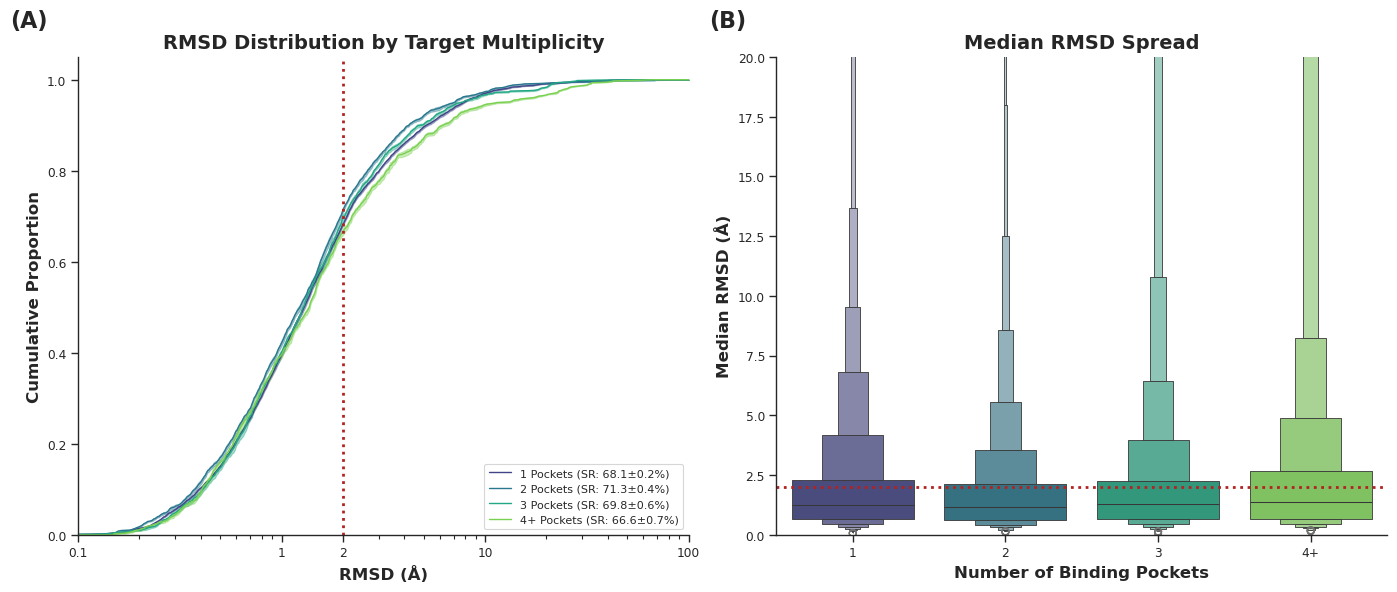

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from scipy.interpolate import interp1d

def plot_multiplicity_effect(df_bs, dfs):

    sns.set_theme(style="ticks", context="paper")
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))


    df_bs["PDB"] = df_bs["Target"].apply(lambda x: x.split("_")[-1])


    def get_group(x):
        return str(x) if x <= 3 else '4+'

    df_bs['Pocket_Group'] = df_bs['Multiplicity'].apply(get_group)
    groups = ['1', '2', '3', '4+']


    common_rmsd_grid = np.logspace(np.log10(0.1), np.log10(100), 500)


    group_stats = {g: {'cdfs': [], 'success_rates': []} for g in groups}
    palette = sns.color_palette("viridis", len(groups))


    for i, df_run in enumerate(dfs):
        df_combined = pd.merge(df_run, df_bs, on='PDB')

        for g in groups:
            subset = df_combined[df_combined['Pocket_Group'] == g]
            if not subset.empty:
                rmsd_vals = subset['rmsd'].dropna().values


                sr = (rmsd_vals <= 2.0).mean() * 100
                group_stats[g]['success_rates'].append(sr)


                data_sorted = np.sort(rmsd_vals)
                y_vals = np.arange(1, len(data_sorted) + 1) / len(data_sorted)
                interp_func = interp1d(data_sorted, y_vals, bounds_error=False, fill_value=(0, 1))
                group_stats[g]['cdfs'].append(interp_func(common_rmsd_grid))


    ax1 = axes[0]
    print("-" * 50)
    print(f"{'Pocket Group':<15} | {'Success Rate (Median ± SD)%':<25}")
    print("-" * 50)

    for i, g in enumerate(groups):
        if group_stats[g]['cdfs']:
            cdfs_array = np.array(group_stats[g]['cdfs'])
            median_cdf = np.median(cdfs_array, axis=0)
            std_cdf = np.std(cdfs_array, axis=0)


            med_sr = np.median(group_stats[g]['success_rates'])
            std_sr = np.std(group_stats[g]['success_rates'])
            label = f"{g} Pockets (SR: {med_sr:.1f}±{std_sr:.1f}%)"
            print(f"{g:<15} | {med_sr:.2f} ± {std_sr:.2f}")


            ax1.fill_between(common_rmsd_grid,
                            np.maximum(0, median_cdf - std_cdf),
                            np.minimum(1, median_cdf + std_cdf),
                            color=palette[i], alpha=0.4)

            ax1.plot(common_rmsd_grid, median_cdf, color=palette[i], lw=1, label=label)

    ax1.axvline(x=2.0, color='firebrick', linestyle=':', lw=2)
    ax1.set_xscale('log')
    ax1.xaxis.set_major_formatter(ticker.ScalarFormatter())
    ax1.set_xticks([0.1, 1, 2, 10, 100])
    ax1.set_xticklabels(['0.1', '1', '2', '10', '100'])
    ax1.set_xlim(0.1, 100)
    ax1.set_ylim(0, 1.05)
    ax1.set_title('RMSD Distribution by Target Multiplicity', fontsize=14, fontweight='bold')
    ax1.set_xlabel('RMSD (Å)', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Cumulative Proportion', fontsize=12, fontweight='bold')
    ax1.legend(loc='lower right', fontsize=8)


    ax2 = axes[1]
    all_runs_concat = pd.concat(dfs)
    df_pdb_median = all_runs_concat.groupby('PDB')['rmsd'].median().reset_index()
    df_final_box = pd.merge(df_pdb_median, df_bs, on='PDB')

    sns.boxenplot(data=df_final_box, x='Pocket_Group', y='rmsd', order=groups, palette=palette, ax=ax2)
    ax2.axhline(y=2.0, color='firebrick', linestyle=':', lw=2)
    ax2.set_ylim(0, 20)
    ax2.set_title('Median RMSD Spread', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Number of Binding Pockets', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Median RMSD (Å)', fontsize=12, fontweight='bold')
    axes[0].text(-0.05, 1.1, '(A)', transform=axes[0].transAxes, fontsize=16, fontweight='bold', va='top', ha='right')
    axes[1].text(-0.05, 1.1, '(B)', transform=axes[1].transAxes, fontsize=16, fontweight='bold', va='top', ha='right')

    sns.despine()
    plt.tight_layout()
    plt.savefig(f'{YOUR_PATH}/rmsd_validation/multiplicity_with_sd.png', dpi=600)
    plt.show()

if __name__ == "__main__":
    df_bs = pd.read_csv(f"{YOUR_PATH}/Data/binding_site_multiplicity.csv")
    dfs = [pd.read_csv(f"{YOUR_PATH}/rmsd_validation/MultiRun/run{i}_rmsd_results_fixed.csv")
           for i in range(1, 6)]
    plot_multiplicity_effect(df_bs, dfs)

# Perturbation Anlysis  of he weights

In [ ]:
import pandas as pd
df = pd.read_csv(f'{YOUR_PATH}/rmsd_validation/Parameter_optimization_ALL.csv')
print(df.columns)
display(df)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score


def normalize_vina(value):
    if value <= -18: return 1
    elif value >= 18: return 0
    else: return (-value + 18) / 36


df['norm_vina'] = df['Vina_Activity'].apply(normalize_vina)
df['target'] = (df['rmsd'] <= 2).astype(int)


best_weights = np.array([0.270, 0.378, 0.324, 0.027])
best_threshold = 0.5
feature_cols = ['Interaction_Similarity', 'norm_vina', 'Mimic_Score', 'Tanimoto2D']


perturbations = np.linspace(0.5, 1.5, 21) # From 50% to 150% of original weight
sensitivity_results = []

for i, col in enumerate(feature_cols):
    for p in perturbations:

        current_weights = best_weights.copy()
        original_val = current_weights[i]
        new_val = original_val * p


        current_weights[i] = new_val
        other_indices = [idx for idx in range(len(feature_cols)) if idx != i]
        sum_others = sum(current_weights[other_indices])

        if sum_others > 0:
            adjustment_factor = (1 - new_val) / sum_others
            for idx in other_indices:
                current_weights[idx] *= adjustment_factor


        scores = np.dot(df[feature_cols], current_weights)
        preds = (scores > best_threshold).astype(int)
        f1 = f1_score(df['target'], preds, zero_division=0)

        sensitivity_results.append({
            'Feature': col,
            'Perturbation': (p - 1) * 100,
            'F1_Score': f1
        })

sens_df = pd.DataFrame(sensitivity_results)


name_mapping = {
    'Interaction_Similarity': 'IntSim',
    'norm_vina': 'IntDock',
    'Mimic_Score': '3Dsim',
    'Tanimoto2D': '2Dsim'
}
sens_df['Feature'] = sens_df['Feature'].replace(name_mapping)


plt.figure(figsize=(10, 6))


sns.set_style("ticks")


plot = sns.lineplot(
    data=sens_df,
    x='Perturbation',
    y='F1_Score',
    hue='Feature',
    palette='Set2',
    linewidth=2.5
)


sns.despine()

plt.axvline(x=0, color='firebrick', linestyle='--', alpha=0.6, label='CASF2016 Weights')
plt.title('Weight Sensitivity Analysis (F1 Stability)', fontsize=14, fontweight='bold', pad=15)


plt.xlabel('Weight Perturbation (%)', fontsize=12, fontweight='bold')
plt.ylabel('F1 Score', fontsize=12, fontweight='bold')

plt.legend(title='Parameters', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig(f"{YOUR_PATH}/Images/Weight_sensitivity_analysis.png", dpi = 400)
plt.show()


# RMSD comparison with SAIR for Overlapping ligands

In [ ]:
import pandas as pd
df = pd.read_csv(f"{YOUR_PATH}/rmsd_validation/rmsd_SAIR_results_all_confidences.csv")
display(df)

,SAIR_id,LigandEXT_id,protein_rmsd,ligand_rmsd,confidence_score_SAFR,confidence_score_SAIR
0,118511,1336692,0.338760,0.838361,0.532282,0.760199
1,650852,1630744,0.334686,1.769551,0.569580,0.861054
2,687210,1299343,0.376788,1.507688,0.202214,0.855946
3,509837,1845263,0.352217,0.574811,0.686453,0.935306
4,600911,1769670,0.738651,1.464988,0.671140,0.801617
...,...,...,...,...,...,...
59766,174227,1377704,0.480705,2.454185,0.528643,0.839713
59767,717175,1661398,0.467544,0.878525,0.586888,0.779458
59768,716867,1646364,0.484104,1.677326,0.451896,0.767758
59769,127022,963385,0.403789,2.463581,0.545056,0.817782


In [12]:
df.dropna(subset=['ligand_rmsd'], inplace=True)

total_entries = len(df)

if total_entries > 0:

            subset_df = df[df['ligand_rmsd'] <= 2]


            count_le_2 = len(subset_df)


            percentage = (count_le_2 / total_entries) * 100

            print("-" * 30)
            print(f"Total valid entries: {total_entries}")
            print(f"Entries with ligand_rmsd <= 2: {count_le_2}")
            print(f"Percentage: {percentage:.2f}%")

else:
            print("The 'ligand_rmsd' column contains no valid data.")

------------------------------
Total valid entries: 59771
Entries with ligand_rmsd <= 2: 25090
Percentage: 41.98%


In [13]:

df_cs = df[df["confidence_score_SAIR"] > 0.8]
df_cs = df_cs[df_cs["confidence_score_SAFR"] > 0.6]
total_entries = len(df_cs)

if total_entries > 0:

            subset_df = df_cs[df_cs['ligand_rmsd'] <= 2]

            count_le_2 = len(subset_df)


            percentage = (count_le_2 / total_entries) * 100

            print("-" * 30)
            print(f"Total valid entries: {total_entries}")
            print(f"Entries with ligand_rmsd <= 2: {count_le_2}")
            print(f"Percentage: {percentage:.2f}%")

else:
            print("The 'ligand_rmsd' column contains no valid data.")

------------------------------
Total valid entries: 14882
Entries with ligand_rmsd <= 2: 9401
Percentage: 63.17%


In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

df_cs = df[df["confidence_score_SAFR"] > 0.6]
df_cs.dropna(subset=['ligand_rmsd'], inplace=True)
df_cs = df_cs[df_cs["confidence_score_SAIR"] > 0.8]

df.dropna(subset=['ligand_rmsd'], inplace=True)
df_cs.dropna(subset=['ligand_rmsd'], inplace=True)

sns.set_theme(style="ticks")
plt.figure(figsize=(12, 7))

sns.histplot(data=df, x='ligand_rmsd', log_scale=True, kde=True, bins=50,
             color="lightgray", label='All Poses (N=59,798)')


sns.histplot(data=df_cs[df_cs["confidence_score_SAIR"] > 0.8], x='ligand_rmsd', log_scale=True, kde=True, bins=50,
             color="firebrick", label='High-Confidence Poses (N=14,883)')
sns.despine()

plt.title('', fontsize=18, weight='bold')
plt.xlabel('Ligand RMSD (Å)', fontsize=14, weight='bold')
plt.ylabel('', fontsize=14)


plt.axvline(x=1, color='gray', linestyle='--', linewidth=2, label='RMSD = 1 Å')
plt.axvline(x=2, color='black', linestyle='--', linewidth=2, label='RMSD = 2 Å (Success Threshold)')

plt.legend()
plt.tight_layout()

plt.show()
plt.savefig(f"{YOUR_PATH}/Images/SAIR_Comparison_rmsd_ligands.png", dpi = 800)

In [14]:
display(df["ligand_rmsd"].median())
display(df_cs["ligand_rmsd"].median())

2.4317547519185734

1.5157417999361136

# Computational time analysis

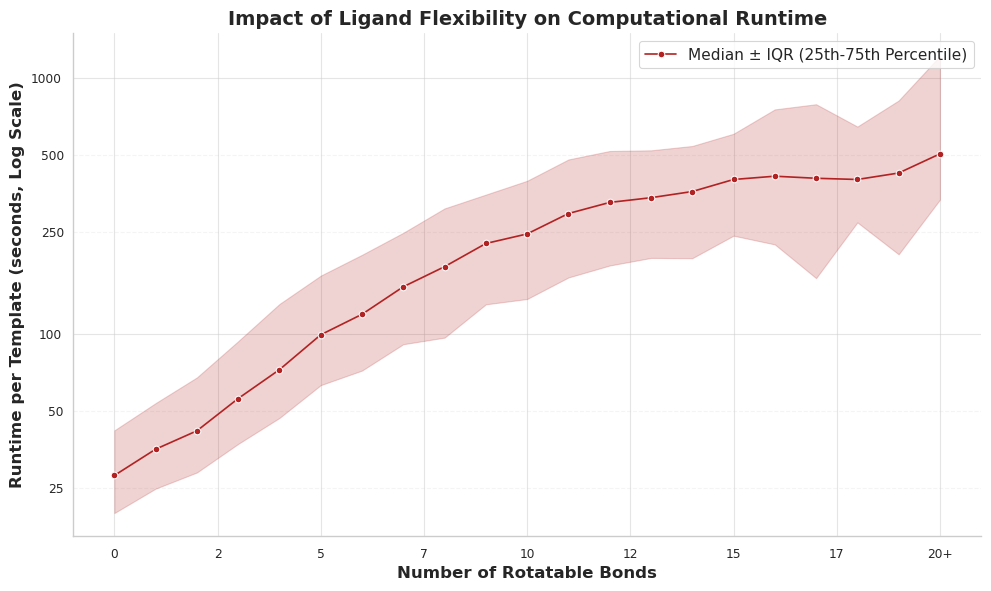

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker


all_dfs = []
for i in range(1, 6):
    file_path = f"{YOUR_PATH}/rmsd_validation/MultiRun/log_run_{i}_fixed.csv"
    df = pd.read_csv(file_path)
    df['Run'] = i
    all_dfs.append(df)
combined_df = pd.concat(all_dfs, ignore_index=True)
filtered_df = combined_df.copy()

MAX_BONDS = 20
filtered_df['Rotatable_Bonds'] = filtered_df['Rotatable_Bonds'].clip(upper=MAX_BONDS)

sns.set_theme(style="whitegrid", context="paper")
plt.figure(figsize=(10, 6))

ax = sns.lineplot(data=filtered_df, x='Rotatable_Bonds', y='Time_per_template',
                  estimator='median', errorbar=('pi', 50),
                  marker='o', color='firebrick', label='Median ± IQR (25th-75th Percentile)')

plt.yscale('log')

ax.yaxis.set_major_locator(ticker.LogLocator(base=10.0, numticks=10))
ax.yaxis.set_minor_locator(ticker.LogLocator(base=10.0, subs=(2.5, 5), numticks=10))

formatter = ticker.ScalarFormatter()
formatter.set_scientific(False)
ax.yaxis.set_major_formatter(formatter)
ax.yaxis.set_minor_formatter(formatter)


ticks = ax.get_xticks()
labels = [f"{int(tick)}" if tick < MAX_BONDS else f"{MAX_BONDS}+" for tick in ticks if tick >= 0 and tick <= MAX_BONDS]
ax.set_xticks([t for t in ticks if 0 <= t <= MAX_BONDS])
ax.set_xticklabels(labels)


plt.title('Impact of Ligand Flexibility on Computational Runtime', fontsize=14, fontweight='bold')
plt.xlabel('Number of Rotatable Bonds', fontsize=12, fontweight='bold')
plt.ylabel('Runtime per Template (seconds, Log Scale)', fontsize=12, fontweight='bold')

plt.grid(True, which='major', linestyle='-', alpha=0.5)
plt.grid(True, which='minor', linestyle='--', alpha=0.2)

plt.legend(fontsize=11)
sns.despine()
plt.tight_layout()


plt.savefig(f'{YOUR_PATH}/rmsd_validation/runtime_vs_rotatable_bonds.png', dpi=500)
plt.show()

In [7]:

median_time = combined_df["Time_per_template"].median()


q25 = combined_df["Time_per_template"].quantile(0.25)
q75 = combined_df["Time_per_template"].quantile(0.75)


iqr = q75 - q25

print("--- Runtime Statistics ---")
print(f"Median: {median_time:.1f} seconds")
print(f"25th Percentile: {q25:.1f} seconds")
print(f"75th Percentile: {q75:.1f} seconds")
print(f"IQR Spread: {iqr:.1f} seconds\n")


--- Runtime Statistics ---
Median: 94.6 seconds
25th Percentile: 47.1 seconds
75th Percentile: 203.3 seconds
IQR Spread: 156.2 seconds



# Fragment Pose Validation

In [ ]:

from rdkit import Chem
import pandas as pd
mols = Molecules(f"{YOUR_PATH}/Fragment_Validation/SAFR_Fragments.sdf")
display(mols)
df_SAFR = mols.dataframe()

def defragment(mol, polarR: bool = False):
    fragment = Chem.Mol(mol)
    for atom in fragment.GetAtoms():
        if atom.GetAtomicNum() == 0:
            if polarR:
                neighbors = atom.GetNeighbors()
                if neighbors and neighbors[0].GetSymbol() != "C":
                    atom.SetAtomMapNum(0)
                    atom.SetIsotope(0)
                    continue
            atom.SetAtomicNum(1)
            atom.SetIsotope(0)
    try:
        fragment = Chem.RemoveAllHs(fragment, sanitize=True)
        Chem.SanitizeMol(fragment)
        return fragment
    except Exception:
        return None
df_SAFR['mol'] = df_SAFR['mol'].apply(lambda x: defragment(x) if x else None)

df_SAFR = df_SAFR.dropna(subset=['mol']).copy()

def get_key(mol):
    if mol:
        try:
            return Chem.MolToInchiKey(mol)
        except:
            return None
    return None


df_SAFR['inchi_key'] = df_SAFR['mol'].apply(get_key)


mols = Molecules(f"{YOUR_PATH}/Fragment_Validation/FS_crystal_fragments.sdf")
display(mols)
df_crystal = mols.dataframe()
df_crystal['inchi_key'] = df_crystal['mol'].apply(get_key)

<class '__main__.Molecules'>
INFILE:	/home/joan/posal/deliverables/Notebooks/Fragment_Validation/SAFR_Fragments.sdf
SIZE:	4034
READ:	False

<class '__main__.Molecules'>
INFILE:	/home/joan/posal/deliverables/Notebooks/Fragment_Validation/FS_crystal_fragments.sdf
SIZE:	1027
READ:	False

      max_similarity
0           0.479167
1           0.382353
2           0.250000
3           0.437500
4           0.317073
...              ...
4029        0.375000
4030        0.303030
4031        0.303030
4032        0.322581
4033        0.290323

[4034 rows x 1 columns]
== 1:  23

Average Max Similarity: 0.335


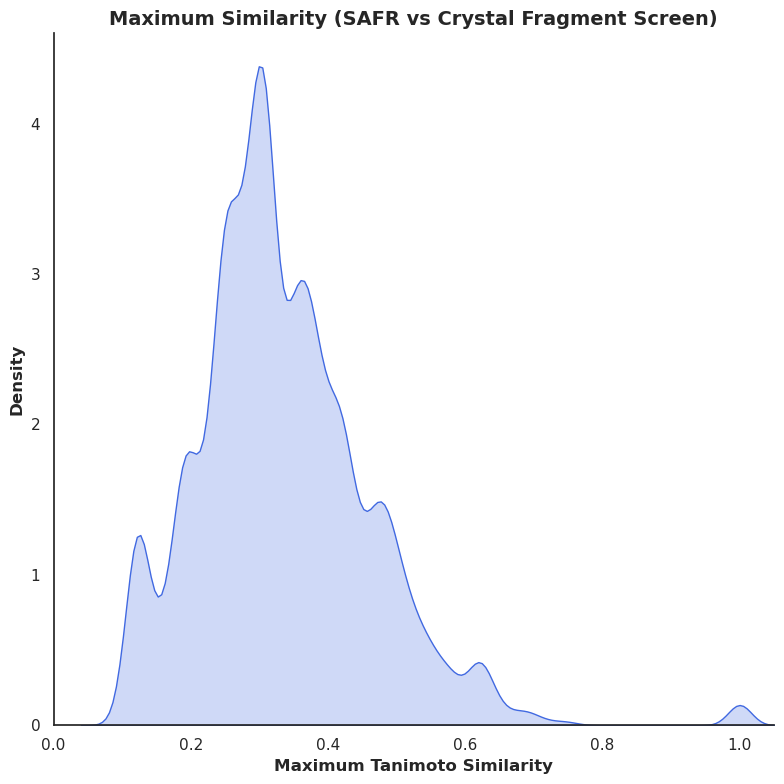

In [ ]:
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns


crystal_fps = [AllChem.GetMorganFingerprintAsBitVect(m, 2, nBits=2048) for m in df_crystal['mol']]

def get_max_tanimoto(query_mol):
    if query_mol is None:
        return 0.0


    query_fp = AllChem.GetMorganFingerprintAsBitVect(query_mol, 2, nBits=2048)

    similarities = DataStructs.BulkTanimotoSimilarity(query_fp, crystal_fps)

    return max(similarities)


df_SAFR['max_similarity'] = df_SAFR['mol'].apply(get_max_tanimoto)

print(df_SAFR[['max_similarity']])
print("== 1: ", len(df_SAFR[df_SAFR['max_similarity'] == 1]))
print(f"\nAverage Max Similarity: {df_SAFR['max_similarity'].mean():.3f}")

sns.set_theme(style="whitegrid")

plt.figure(figsize=(8, 8))
sns.set_style("white")

sns.kdeplot(df_SAFR['max_similarity'], fill=True, color='royalblue', bw_adjust=0.7)
sns.despine()

plt.xlabel('Maximum Tanimoto Similarity', fontsize=12, fontweight = "bold")
plt.ylabel('Density', fontsize=12,fontweight = "bold")
plt.title('Maximum Similarity (SAFR vs Crystal Fragment Screen)', fontsize=14, fontweight = "bold")


plt.xlim(0, 1.05)


plt.tight_layout()
plt.savefig(f"{YOUR_PATH}/Fragment_Validation/Max_Tanimoto.png", dpi = 500)

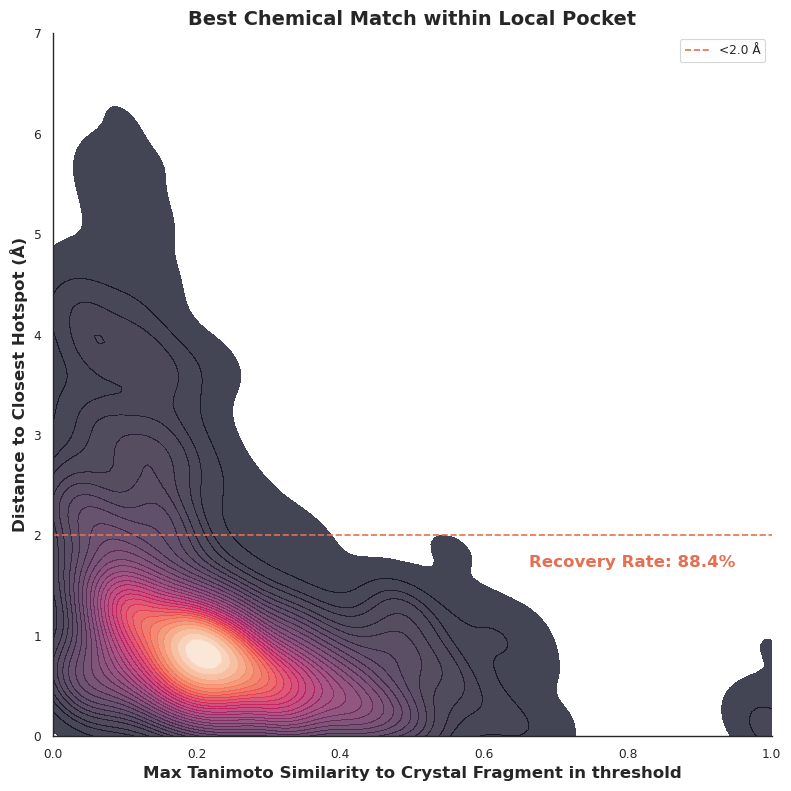

In [ ]:
import numpy as np
from rdkit import Chem, DataStructs
from rdkit.Chem import AllChem
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def get_centroid(mol):
    if mol is None: return None
    conf = mol.GetConformer()
    return conf.GetPositions().mean(axis=0)

crystal_centroids = np.array([get_centroid(m) for m in df_crystal['mol'] if m is not None])
crystal_fps = [AllChem.GetMorganFingerprintAsBitVect(m, 2, nBits=2048) for m in df_crystal['mol'] if m is not None]
def get_max_sim_within_threshold(query_mol, dist_thresh=2.0):
    q_mol = defragment(query_mol)
    if q_mol is None: return np.nan, np.nan

    q_centroid = get_centroid(q_mol)
    q_fp = AllChem.GetMorganFingerprintAsBitVect(q_mol, 2, nBits=2048)

    distances = np.linalg.norm(crystal_centroids - q_centroid, axis=1)

    within_thresh_indices = np.where(distances <= dist_thresh)[0]

    min_dist = np.min(distances)

    if len(within_thresh_indices) > 0:
        subset_fps = [crystal_fps[i] for i in within_thresh_indices]
        similarities = DataStructs.BulkTanimotoSimilarity(q_fp, subset_fps)
        best_local_sim = max(similarities)
    else:
        closest_idx = np.argmin(distances)
        best_local_sim = DataStructs.TanimotoSimilarity(q_fp, crystal_fps[closest_idx])

    return min_dist, best_local_sim

metrics = df_SAFR['mol'].apply(get_max_sim_within_threshold)
df_SAFR[['dist_to_closest', 'max_sim_in_pocket']] = pd.DataFrame(metrics.tolist(), index=df_SAFR.index)

success_rate = len(df_SAFR[df_SAFR["dist_to_closest"] <= 2]) / len(df_SAFR) * 100

plt.figure(figsize=(8, 8))
sns.set_style("white")

ax = sns.kdeplot(
    data=df_SAFR, x='max_sim_in_pocket', y='dist_to_closest',
    fill=True, cmap="rocket", thresh=0.01, levels=30, alpha=0.75
)


plt.axhline(y=2.0, color='#e76f51', linestyle='--', label='<2.0 Å')

plt.text(0.95, 1.8, f'Recovery Rate: {success_rate:.1f}%',
         horizontalalignment='right',
         verticalalignment='top',
         fontsize=12, fontweight='bold', color='#e76f51',
         bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', boxstyle='round,pad=0.5'))


plt.xlim(0, 1.0)
plt.ylim(0, 7)
plt.xlabel('Max Tanimoto Similarity to Crystal Fragment in threshold', fontsize=12, fontweight="bold")
plt.ylabel('Distance to Closest Hotspot (Å)', fontsize=12, fontweight="bold")
plt.title('Best Chemical Match within Local Pocket', fontsize=14, fontweight="bold")
plt.legend(loc='upper right')

sns.despine()
plt.tight_layout()

plt.savefig(f"{YOUR_PATH}/Fragment_Validation/Fragment_Hotspots.png", dpi=500)
plt.show()